# Model 9: Hebbian Learning with Rehearsal and Decay

In Model 8, the presynaptic and postsynaptic neurons were active together during every event. Because Hebbian learning strengthens connections between neurons that fire together, each event effectively represented another repetition/rehearsal of the same memory. As a result, the connection strength continuously increased towards its maximum value.

However, real memories are not constantly being rehearsed. Time can pass without the associated neurons being activated together, allowing the connection to weaken.

In Model 9, I will separate rehearsal events from periods of inactivity. When the neurons fire together, the connection strength will increase according to the Hebbian learning rule. When they do not fire together, the connection strength will decay.

This model will explore how the frequency of rehearsal affects long-term memory strength. I predict that memories rehearsed more frequently will maintain stronger connections, while memories rehearsed less frequently will decay more significantly over time.

Over discrete time steps, we will use the equations:

Δw = ηxy(1 - w), when the neurons co-fire (bounded Hebbian learning from Model 8)

Δw = -ƛw, when the neurons don't co-fire (exponential memory decay from Model 1)

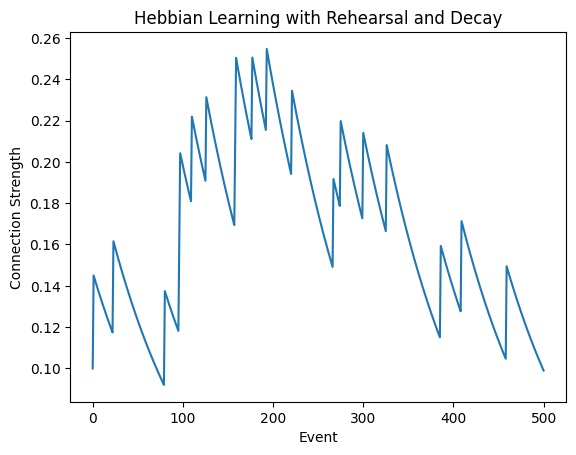

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

presynaptic_activity = 1.0
postsynaptic_activity = 1.0

connection_strength_initial = 0.1
learning_rate = 0.05
decay_rate = 0.01

connection_strength = connection_strength_initial

connection_strengths = [connection_strength] # initialize the list we're plotting with the first value
events = [0]

for i in range(1, 501):

    if (random.random() < 0.05):
        connection_strength = (
            connection_strength_initial
            + learning_rate
            * presynaptic_activity
            * postsynaptic_activity
            * (1 - connection_strength_initial)
        )
    else:
        connection_strength = (
            connection_strength_initial
            - decay_rate * connection_strength_initial
        )
    
    connection_strengths.append(connection_strength)
    events.append(i)

    connection_strength_initial = connection_strength

plt.plot(events, connection_strengths)

plt.xlabel("Event")
plt.ylabel("Connection Strength")
plt.title("Hebbian Learning with Rehearsal and Decay")
plt.show()

## Model 9 Experiment: Effect of Rehearsal Frequnecy

The previous simulation used a 5% probability of rehearsal at each event. However, rehearsal frequency should have a major effect on whether a memory is strengthened, maintained, or forgotten.

To test this, I will simulate several different rehearsal probabilities:

- 1%
- 2.5%
- 5%
- 10%
- 20%

Each model will use the same initial connection strength, learning rate, decay rate, and sequence of random values. This keeps the comparison controlled so that rehearsal probability is the only variable being changed.

When a generated random value is below the rehearsal threshold, the neurons are treated as firing together and the connection strengthens according to the Hebbian learning rule. Otherwise, the connection undergoes decay.

I predict that higher rehearsal probabilities will produce stronger long-term connection strengths, while lower rehearsal probabilities will allow decay to dominate.

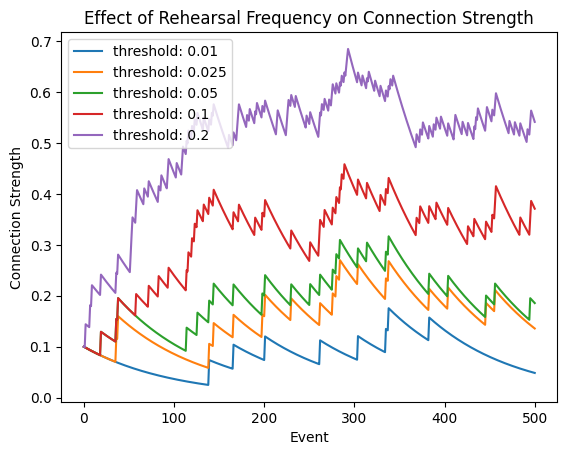

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

presynaptic_activity = 1.0
postsynaptic_activity = 1.0

connection_strength_initial = 0.1
learning_rate = 0.05
decay_rate = 0.01

rehearsal_thresholds = [0.01, 0.025, 0.05, 0.1, 0.2]
random_values = [random.random() for _ in range(500)]

for threshold in rehearsal_thresholds:

    connection_strength = connection_strength_initial
    connection_strengths = [connection_strength_initial] # initialize the list we're plotting with the first value
    events = [0]

    for i in range(1, 501):

        if (random_values[i-1] < threshold):
            connection_strength = (
                connection_strength
                + learning_rate
                * presynaptic_activity
                * postsynaptic_activity
                * (1 - connection_strength)
            )
        else:
            connection_strength = (
                connection_strength
                - decay_rate * connection_strength
            )
        
        connection_strengths.append(connection_strength)
        events.append(i)

    label = "threshold: " + str(threshold)
    plt.plot(events, connection_strengths, label=label)

plt.xlabel("Event")
plt.ylabel("Connection Strength")
plt.title("Effect of Rehearsal Frequency on Connection Strength")
plt.legend()
plt.show()

### Model 9 Interpretation

The graph shows that rehearsal frequency has a strong effect on long-term connection strength.

At low rehearsal probabilities, such as 1% and 2.5%, decay dominates most of the time. The connection strength gradually decreases between rare rehearsal events, and each rehearsal only produces a temporary increase.

At higher rehearsal probabilities, such as 10% and 20%, the connection is reinforced often enough to maintain a much stronger value over time. Although the strength still fluctuates because rehearsal occurs randomly, the overall connection remains significantly higher.

This supports the idea that frequent repetition helps preserve a memory, while infrequent rehearsal allows forgetting to dominate. The model also shows that memory strength does not change smoothly, but instead reflects the competition between random reinforcement events and continuous decay.

This suggests that there may be a rehearsal frequency at which strengthening and decay begin to balance each other, which could be explored more precisely using repeated simulations.

### Model 9 Limitations

This model is still a simplified representation of memory. Rehearsal is modeled as a random event with a fixed probability, whereas real memory rehearsal is influenced by attention, meaning, emotion, and context.

In addition, the model assumes constant learning and decay rates for all events. In real neural systems, these rates may vary depending on the type of memory, the strength of prior learning, and other biological factors.

The model also represents memory strength with a single connection value, while actual memories involve large networks of neurons rather than one isolated synapse.

Finally, because rehearsal is random, a single simulation can be influenced by chance. Running many simulations and averaging the results through a Monte Carlo approach would give a more reliable picture of the relationship between rehearsal frequency and long-term memory strength.

### Next Steps

The next step is to repeat each rehearsal-frequency simulation many times using a Monte Carlo approach. This would reduce the effect of random chance and allow me to compare average connection strengths across rehearsal probabilities.

I could also explore whether there is a critical rehearsal frequency where Hebbian strengthening begins to consistently outweigh decay.

Eventually, I would also like to test how changing other variables; such as presynaptic activity, postsynaptic activity, initial connection strength, learning rate, and decay rate; affects long-term connection strength.